In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("toddler_autism.csv")

In [ ]:
df.shape

(1054, 19)

In [ ]:
df.columns.tolist()

['Case_No',
 'A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Age_Mons',
 'Qchat-10-Score',
 'Sex',
 'Ethnicity',
 'Jaundice',
 'Family_mem_with_ASD',
 'Who completed the test',
 'Class/ASD Traits ']

In [ ]:
df.dtypes

,0
Case_No,int64
A1,int64
A2,int64
A3,int64
A4,int64
A5,int64
A6,int64
A7,int64
A8,int64
A9,int64


In [ ]:
df.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [ ]:
df.isnull().sum()

,0
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


In [ ]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
Case_No,0.0
A1,0.0
A2,0.0
A3,0.0
A4,0.0
A5,0.0
A6,0.0
A7,0.0
A8,0.0
A9,0.0


In [ ]:
print(df['Class/ASD Traits '].value_counts())

Class/ASD Traits 
Yes    728
No     326
Name: count, dtype: int64


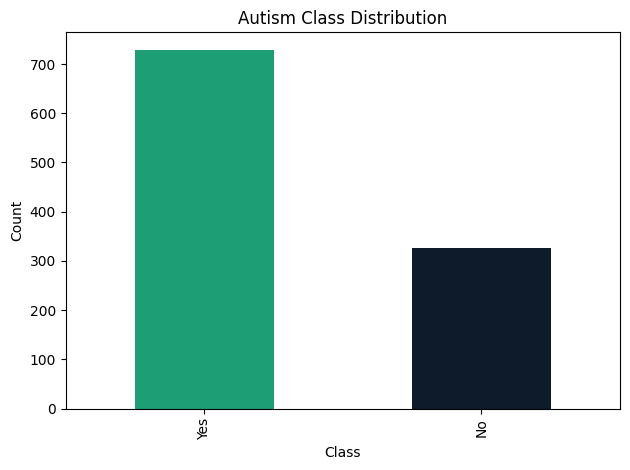

In [ ]:
df['Class/ASD Traits '].value_counts().plot(kind='bar', color=['#1d9e75','#0d1b2a'])
plt.title("Autism Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
q_cols = [col for col in df.columns if col.startswith('A') and col[1:].isdigit()]

In [ ]:
print(q_cols)

['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']


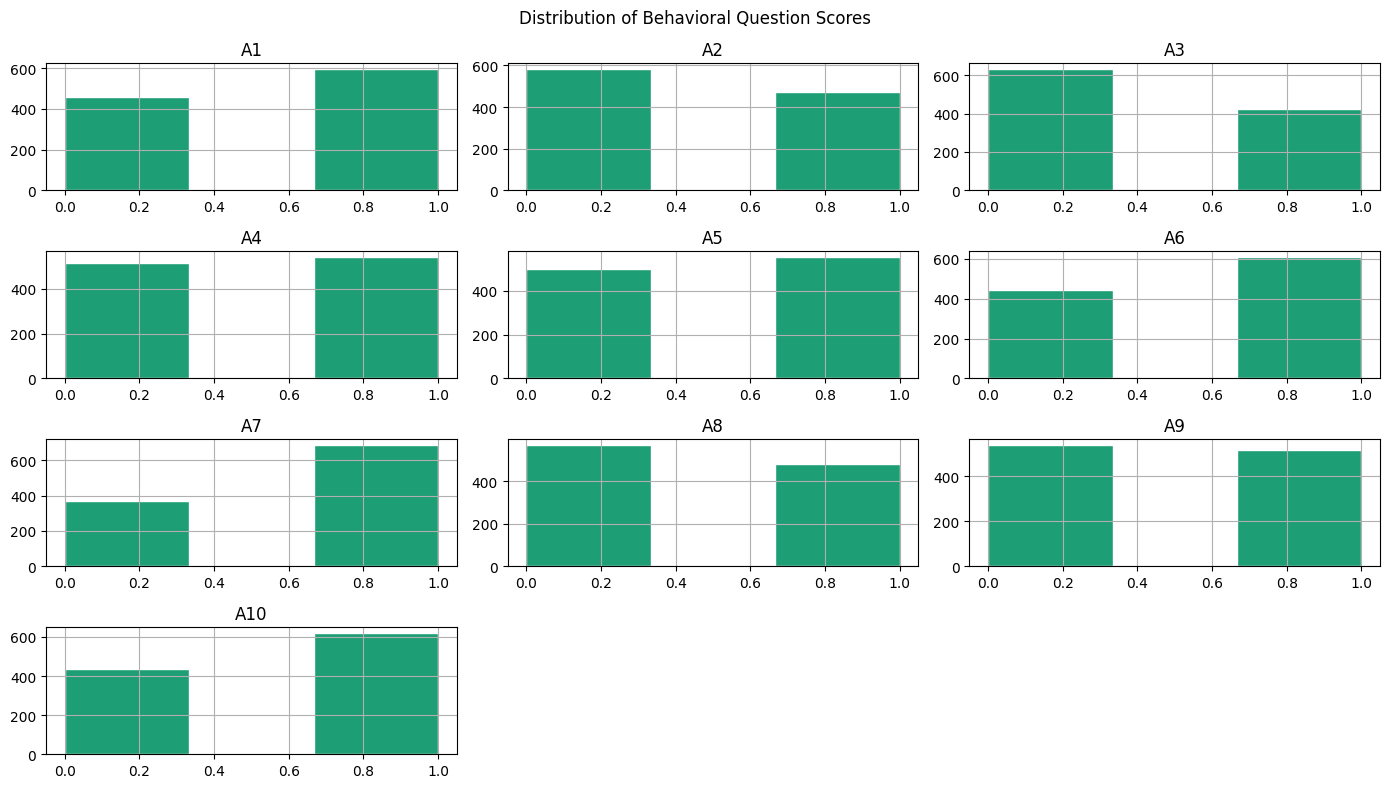

In [ ]:
df[q_cols].hist(figsize=(14, 8), bins=3, color='#1d9e75', edgecolor='white')
plt.suptitle("Distribution of Behavioral Question Scores")
plt.tight_layout()
plt.show()

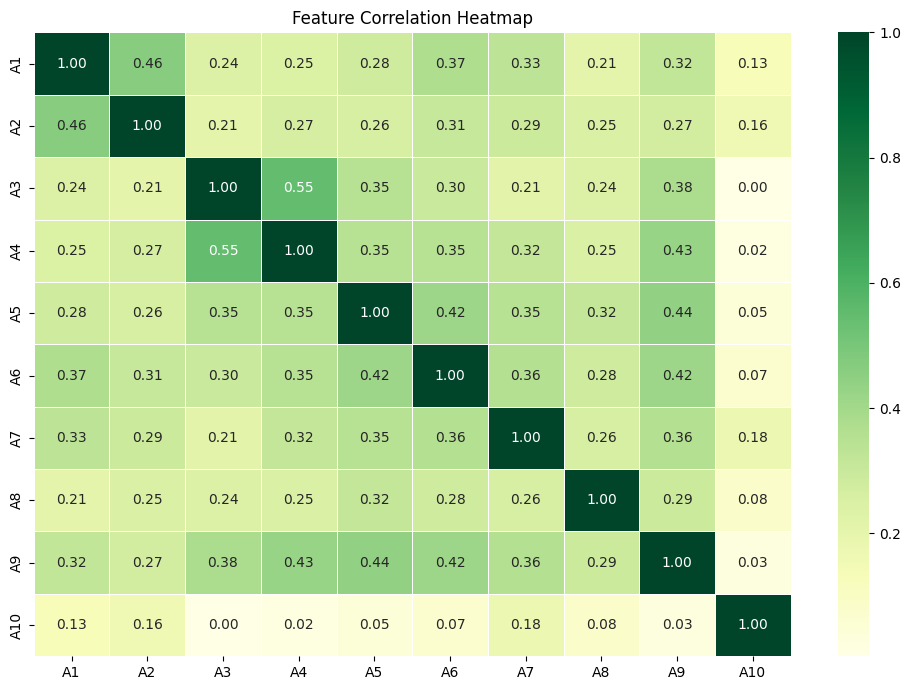

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[q_cols].corr(), annot=True, fmt=".2f",
            cmap="YlGn", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib, os

In [ ]:
df=pd.read_csv('toddler_autism.csv')

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.drop(columns=['Case_No', 'Qchat-10-Score'], inplace=True)

In [ ]:
cat_cols = ['Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD',
            'Who completed the test']

In [ ]:
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip())
    le_dict[col] = le
le_target = LabelEncoder()

In [ ]:
df['Class/ASD Traits'] = le_target.fit_transform(
    df['Class/ASD Traits'].astype(str).str.strip()
)

In [ ]:
X = df.drop(columns=['Class/ASD Traits'])
y = df['Class/ASD Traits']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(le_dict, "models/label_encoders.joblib")
joblib.dump(le_target, "models/target_encoder.joblib")


['models/target_encoder.joblib']

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())

X_train shape: (843, 16)
X_test shape: (211, 16)
y_train distribution: {1: 582, 0: 261}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_res.value_counts().to_dict())

After SMOTE: {1: 582, 0: 582}


In [ ]:
models = {
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "xgboost": XGBClassifier(eval_metric='logloss', random_state=42),
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
}

In [ ]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    joblib.dump(model, f"models/autism_{name}.joblib")
    trained_models[name] = model
    print(f"Trained & saved: autism_{name}.joblib")

print("\nAll models trained!")

Trained & saved: autism_random_forest.joblib
Trained & saved: autism_xgboost.joblib
Trained & saved: autism_logistic_regression.joblib

All models trained!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


  RANDOM FOREST
              precision    recall  f1-score   support

      No ASD       0.93      0.97      0.95        65
     Yes ASD       0.99      0.97      0.98       146

    accuracy                           0.97       211
   macro avg       0.96      0.97      0.96       211
weighted avg       0.97      0.97      0.97       211

ROC-AUC Score: 0.9948


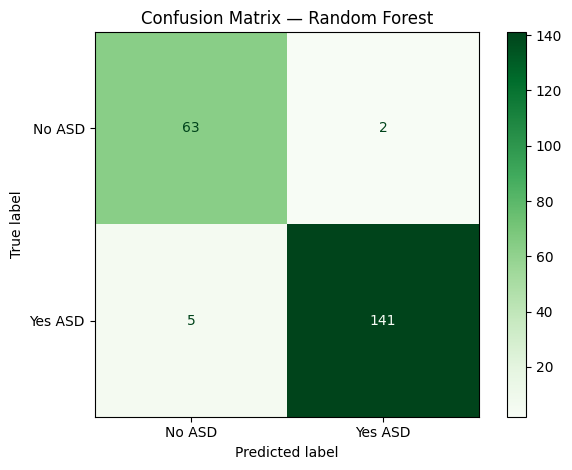


  XGBOOST
              precision    recall  f1-score   support

      No ASD       0.94      0.98      0.96        65
     Yes ASD       0.99      0.97      0.98       146

    accuracy                           0.98       211
   macro avg       0.97      0.98      0.97       211
weighted avg       0.98      0.98      0.98       211

ROC-AUC Score: 0.9995


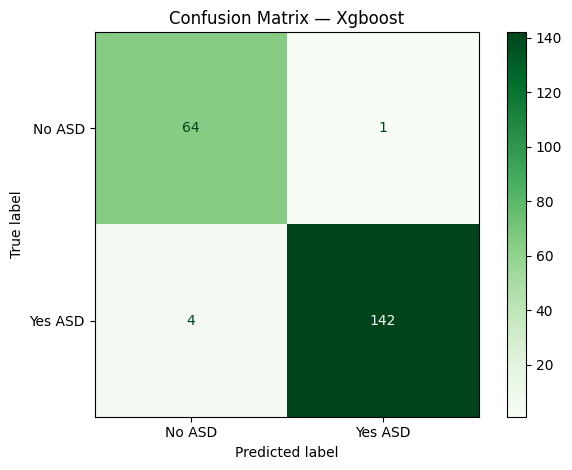


  LOGISTIC REGRESSION
              precision    recall  f1-score   support

      No ASD       1.00      1.00      1.00        65
     Yes ASD       1.00      1.00      1.00       146

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

ROC-AUC Score: 1.0000


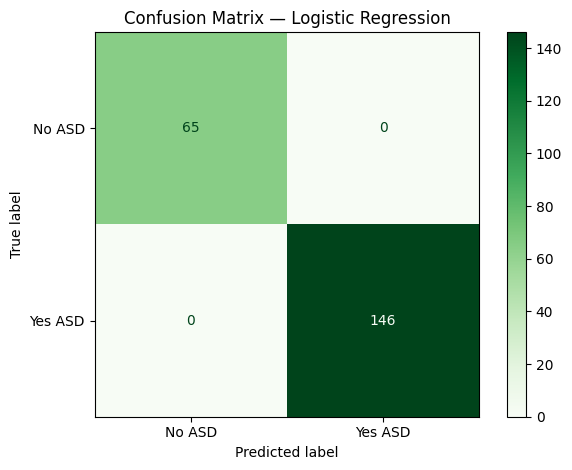

In [ ]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*45}")
    print(f"  {name.upper().replace('_', ' ')}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['No ASD', 'Yes ASD']))
    print(f"ROC-AUC Score: {auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'Yes ASD'])
    disp.plot(cmap='Greens')
    plt.title(f"Confusion Matrix — {name.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
feature_names = X.columns.tolist()

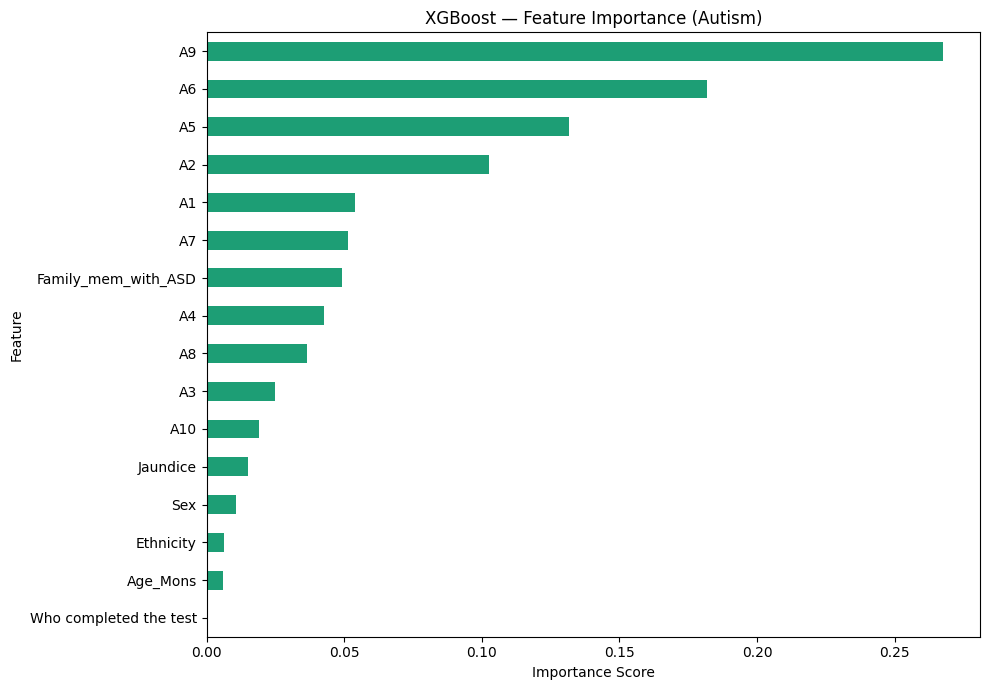

               Feature  Importance
                    A9    0.267591
                    A6    0.181917
                    A5    0.131635
                    A2    0.102515
                    A1    0.053761
                    A7    0.051454
   Family_mem_with_ASD    0.049268
                    A4    0.042789
                    A8    0.036551
                    A3    0.024936
                   A10    0.019206
              Jaundice    0.015138
                   Sex    0.010718
             Ethnicity    0.006446
              Age_Mons    0.006073
Who completed the test    0.000000


In [ ]:
xgb_model = trained_models['xgboost']
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

feat_df.plot(kind='barh', x='Feature', y='Importance',
             figsize=(10, 7), color='#1d9e75', legend=False)
plt.title("XGBoost — Feature Importance (Autism)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

In [42]:
import numpy as np
import joblib

In [43]:
joblib.dump(trained_models['xgboost'], "models/autism_final_model.joblib")
print("Final model saved!")


Final model saved!


In [44]:
feature_order = X.columns.tolist()
print("Feature order:", feature_order)

Feature order: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test']


In [45]:
def predict_autism(input_dict):
    model = joblib.load("models/autism_final_model.joblib")
    scaler = joblib.load("models/scaler.joblib")

    X_input = pd.DataFrame([input_dict], columns=feature_order)
    X_scaled = scaler.transform(X_input)


    pred = model.predict(X_scaled)[0]
    proba = model.predict_proba(X_scaled)[0]
    confidence = round(max(proba) * 100, 2)

    return {
        "prediction": "Yes - ASD Traits Detected" if pred == 1 else "No - ASD Traits Not Detected",
        "confidence": f"{confidence}%",
        "risk_level": "High" if proba[1] >= 0.7 else "Moderate" if proba[1] >= 0.4 else "Low"
    }

sample = {
    'A1': 1, 'A2': 1, 'A3': 0, 'A4': 1, 'A5': 1,
    'A6': 1, 'A7': 0, 'A8': 1, 'A9': 1, 'A10': 0,
    'Age_Mons': 36, 'Sex': 1, 'Ethnicity': 4,
    'Jaundice': 1, 'Family_mem_with_ASD': 0,
    'Who completed the test': 2
}

result = predict_autism(sample)
print("\nSample Prediction:")
print(f"  Result     : {result['prediction']}")
print(f"  Confidence : {result['confidence']}")
print(f"  Risk Level : {result['risk_level']}")



Sample Prediction:
  Result     : Yes - ASD Traits Detected
  Confidence : 99.98999786376953%
  Risk Level : High


In [46]:
from google.colab import files

files.download("models/autism_final_model.joblib")
files.download("models/scaler.joblib")
files.download("models/label_encoders.joblib")
files.download("models/target_encoder.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>